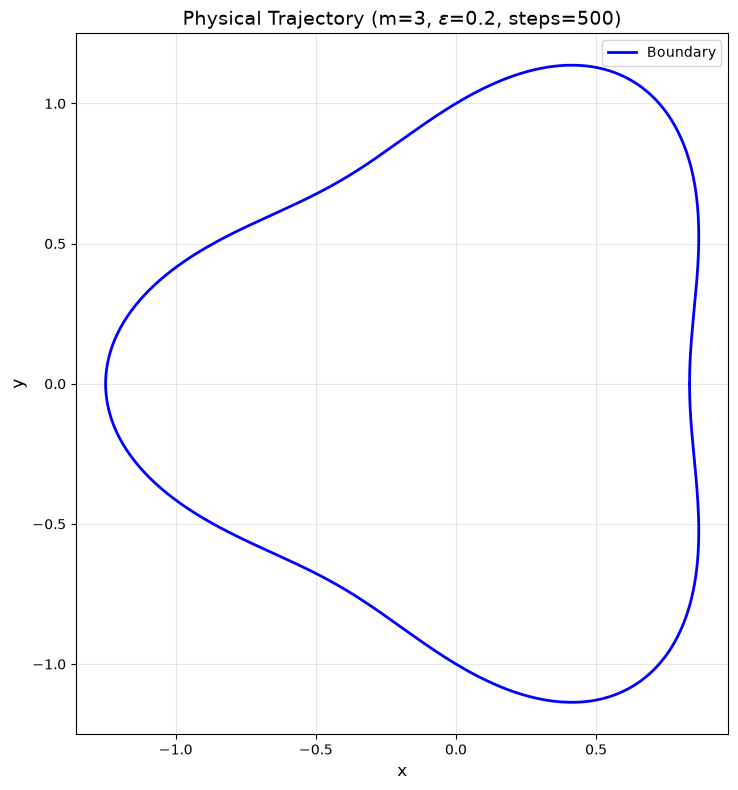

In [8]:
import matplotlib.pyplot as plt
import numpy as np
# from billiard_engine import BilliardsNonTimeDependent
from oval_like import OvalLikeBilliard

def plot_boundary(billiard: OvalLikeBilliard, ax=None, num_points=1000):
    """
    Plot the boundary of the billiard.

    OvalLikeBilliard.boundary() actually gives us the _radius_ of the billiard at each
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    boundary_points = billiard.boundary(num_points=num_points)
    # The * operator "unpacks" the list into separate arguments for zip()
    x_tuples, y_tuples = zip(*boundary_points)

    # Note: zip() returns tuples. If you explicitly need lists, wrap them:
    x_values = list(x_tuples)
    y_values = list(y_tuples)
    ax.plot(x_values, y_values, "b-", linewidth=2, label="Boundary")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    return ax
    
# 1. Define Initial Conditions
theta_0 = np.pi + 0.002
alpha_0 = np.pi / 3.0
eccentricity = 0.2
iterations = 500

# 2. Initialize the Simulator
billiard = OvalLikeBilliard(r0=1.0, eccentricity=eccentricity, mode=3)

# 3. Generate the Trajectory Data
# We discard the phase space data (_) and keep the Cartesian points
# _, cartesian_points = sim.single_trajectory(
#     theta_initial=theta_0, 
#     alpha_initial=alpha_0, 
#     max_iterations=iterations
# )

# 4. Setup the Plot
fig, ax = plt.subplots(figsize=(8, 8))

# 5. Plot the Boundary and Trajectories
# plot_boundary defaults to blue ('b-')
plot_boundary(billiard, ax=ax)

# plot_trajectories defaults to red ('r.' and 'r-')
# sim.plot_trajectories(trajectory_data=cartesian_points, ax=ax)

# 6. Styling
ax.set_title(f"Physical Trajectory (m={billiard.m}, $\epsilon$={billiard.eccentricity}, steps={iterations})", fontsize=14)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)

plt.tight_layout()
plt.show()